# Código desarrollado para obtener los resultados del proyecto

## Proceso de cargar y unir datos.

In [2]:
# Importación de librerías.
import pandas as pd
import numpy as np

# 1. Variables de proceso
df_x = pd.read_csv(
        "datos_entrada/secom.data",
        delim_whitespace=True,
        header=None,
        na_values="NaN")

# 2. Etiquetas y fecha
df_y = pd.read_csv(
        "datos_entrada/secom_labels.data",
        sep=r'\s+',           # separa por espacios
        header=None,
        names=['fail', 'timestamp'], 
        parse_dates=['timestamp'])

# 3. Unir en un solo DataFrame
secom = pd.concat([df_x, df_y], axis=1)

# 4. Vista rápida
print(secom.shape)          # (1567, 592)
print(secom.fail.value_counts())
print(secom.isna().mean().mean())   # ≈ 0.045


/tmp/ipykernel_6940/2378848369.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_x = pd.read_csv(


(1567, 592)
fail
-1    1463
 1     104
Name: count, dtype: int64
0.04522219251798065


/tmp/ipykernel_6940/2378848369.py:13: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_y = pd.read_csv(


## Limpieza básica.

Los valores faltantes, se debe descartar columnas con $>40\%$ de Nan o rellenar con mediana, pero se debe de documentar la decision que se va a tomar.

Para calcular el porcentaje de valores faltantes por columna, primero cuantificamos cuantos $Nan$ hay en cada variable para saber en qué columnas conviene aplicar uno u otro criterio.

In [17]:
import pandas as pd

# Supongamos que ya cargaste el DataFrame “secom” como en el ejemplo anterior:
# secom = pd.concat([df_x, df_y], axis=1)

# Calculamos el porcentaje de NaN en cada columna:
pct_missing = secom.isna().mean() * 100

# Lo convertimos en DataFrame para documentar:
missing_df = pct_missing.reset_index()
missing_df.columns = ['variable', 'pct_nan']
missing_df = missing_df.sort_values('pct_nan', ascending=False)

# Vista rápida de las primeras filas (más valores faltantes):
print(missing_df.head(10))


    variable    pct_nan
157      157  91.193363
292      292  91.193363
293      293  91.193363
158      158  91.193363
492      492  85.577537
358      358  85.577537
85        85  85.577537
220      220  85.577537
246      246  64.964901
109      109  64.964901


Con la tabla anterior se puede documentar exactamente qué columnas exceden el $40\%$ de faltantes y cuales no. A partir de aquí, podemos definir la regla:

- *Regla A (descartar)*: si $pct_nan$ $>$ $40$, descarta la variable completamente.
- *Regla B (imputar)*: si $0$ $<$ $pct_nan$ $\leq$, imputar (rellenar) con la mediana de la columna.
- *Regla C (sin NaN)*: si $pct_nan = 0$ no se realiza nada (la dejamos tal y como esta).

## Aplicar la regla y documentar la decisión.

### Columnas a descartar

In [18]:
# Criterio: pct_nan > 40 %
cols_to_drop = missing_df.loc[missing_df['pct_nan'] > 40, 'variable'].tolist()
print(f"Columnas con >40 % de NaN (se descartan): {cols_to_drop[:10]} ... (total {len(cols_to_drop)})")


Columnas con >40 % de NaN (se descartan): [157, 292, 293, 158, 492, 358, 85, 220, 246, 109] ... (total 32)


### Columnas a imputar ($0\% < pct_nan \leq 40\% $).

In [19]:
cols_to_impute = missing_df.loc[
    (missing_df['pct_nan'] > 0) & (missing_df['pct_nan'] <= 40),
    'variable'
].tolist()
print(f"Columnas con 0 % < NaN ≤ 40 % (imputar con mediana): {len(cols_to_impute)} variables")


Columnas con 0 % < NaN ≤ 40 % (imputar con mediana): 506 variables


### Columnas sin NaN.

In [20]:
cols_no_missing = missing_df.loc[missing_df['pct_nan'] == 0, 'variable'].tolist()
print(f"Columnas sin NaN: {len(cols_no_missing)} variables")


Columnas sin NaN: 55 variables


Ahora, ya se tiene exactamente cuántas columnas caen en cada categoría. Para documentarlo, generamos un pequeño resumen en forma de tabla.

In [21]:
# Crear una columna “acción” en el DataFrame missing_df:
def accion(pct):
    if pct > 40:
        return 'descartar'
    elif pct > 0:
        return 'imputar_mediana'
    else:
        return 'sin_na'

missing_df['accion'] = missing_df['pct_nan'].apply(accion)

# Mostrar las primeras filas para documentar en tu reporte:
print(missing_df.head(15))


    variable    pct_nan     accion
157      157  91.193363  descartar
292      292  91.193363  descartar
293      293  91.193363  descartar
158      158  91.193363  descartar
492      492  85.577537  descartar
358      358  85.577537  descartar
85        85  85.577537  descartar
220      220  85.577537  descartar
246      246  64.964901  descartar
109      109  64.964901  descartar
110      110  64.964901  descartar
111      111  64.964901  descartar
518      518  64.964901  descartar
516      516  64.964901  descartar
245      245  64.964901  descartar


## ¿Por qué esta regla?

1. Descartar $>40\% $ de faltantes.
   - Si se elimina menos umbral (por ejemplo, $30\%$, se podría desechar demasiadas variables críticas.
   - Si se tolera más (por ejemplo $50\%$ se estaría imputando datos donde casi la mitad de las observaciones son originalmente $NaN$, lo cual puede sesgar el análisis de control (es decir, límites de control poco fiables).
   - El $40\%$ es un balance común en la literatura de *data cleaning* para SPC: se descarta la variable cuando más de 2 de cada 5 mediciones ausentes.
2. Imputar con mediana para $0\% <$ faltantes $\leq 40\%$.
   - La mediana es robusta frente a valores atípicos.
   - Mantienes la simplicidad de las gráficas de control (no se introducen ditribuciones extrañas).
   - Documentar: "Se eligió la mediana porque minimiza el impacto de outliers y conserva la tendencia central de esa variable en particular".
3. Variables sin faltantes.
   - No requieren transformación.
   - Conserva la información original.

En el reporte, en la sección *Limpieza de datos*, podemos escribir:
- Para cada una de las 590 variables de proceso, se calculó el porcentaje de valores faltantes ($NaN$).
- Se descartaron las columnas con más de $40\%$ de datos faltantes (en total X columnas), pues imputar en dichas variables podría introducir sesgos importantes y reducir la fiabilidad de las cartas de control.
- En las variables con entre $0\%$ y $40\%$ de datos faltantes (Y columnas), se rellenó cada valor faltante con la mediana de la variable correspondiente, a fin de conservar la tendencia central sin verse afectada por posibles valores atípicos.
- Las variables sin faltantes (Z columnas) quedarón intactas.

## Cartas de Control para mis datos discretos (Pass / Fail) de SECOM.

1. **Carta p**: proporción de lotes defectuosos por subgrupo.
2. **Carta np**: número de lotes defectuosos por subgrupo.
3. **Carta c**: número de defectuosos por subgrupo (equivalente a la *np* cuando cada unidad es un lote).

Supuestos:
- Cada subgrupo está formado por 5 lotes consecutivos.
- La columna *fail* vale 1 si el lote es defectuoso y -1 si es bueno, según el archivo *secom_labels.data*.

/tmp/ipykernel_6940/1045674088.py:14: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_y = pd.read_csv(


Tamaños de cada subgrupo (deben ser 5, excepto quizás el último):
fail
5    313
2      1
Name: count, dtype: int64 

p̄  = 0.0662
UCL_p = 0.3999
LCL_p = 0.0000



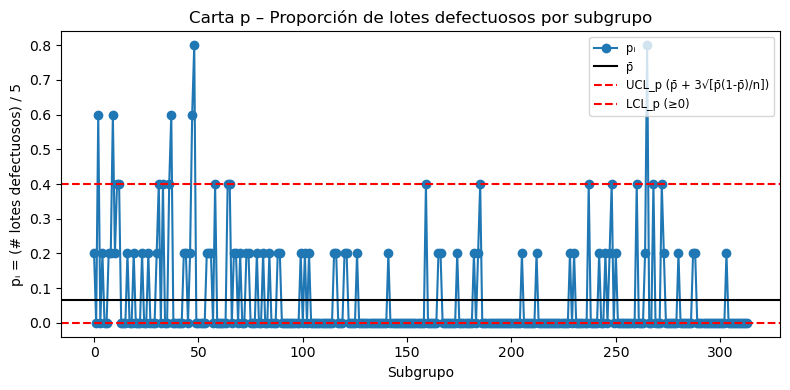

np̄  = 0.3312
UCL_np = 1.9996
LCL_np = 0.0000



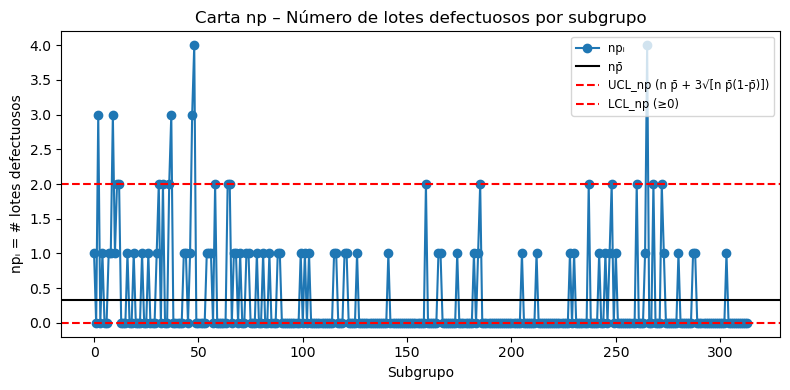

c̄  = 0.3312
UCL_c = 2.0577
LCL_c = 0.0000



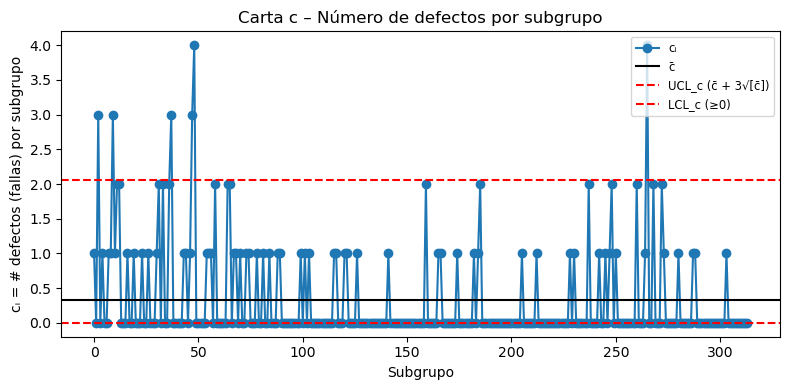

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) CARGA DE DATOS
# -----------------
# En este ejemplo se asume que ya descomprimiste secom.zip y tienes:
#   - secom.data
#   - secom_labels.data
#
# Ajusta las rutas si es necesario.

# 1.1. Cargar etiquetas (fail + timestamp)
df_y = pd.read_csv(
    "datos_entrada/secom_labels.data",
    sep=r"\s+",
    header=None,
    names=["fail", "timestamp"],
    parse_dates=["timestamp"]
)

# 1.2. Ordenar cronológicamente y resetear índices
df_y = df_y.sort_values("timestamp").reset_index(drop=True)

# 1.3. Asegurarnos de que “fail” sea 1 para defectuoso, 0 para bueno
#     (en SECOM, fail=1 ➔ defectuoso, fail=-1 ➔ buen lote)
df_y["fail"] = df_y["fail"].map({1: 1, -1: 0})

# 2) FORMAR SUBGRUPOS RACIONALES
# -------------------------------
# Definimos subgrupos de tamaño n = 5 lotes (consecutivos en fecha)
n = 5
df_y["subgroup"] = (df_y.index // n)

# 2.1. Contar cuántos lotes hay en cada subgrupo (debe ser n, salvo al final)
counts_per_group = df_y.groupby("subgroup")["fail"].size()
print("Tamaños de cada subgrupo (deben ser 5, excepto quizás el último):")
print(counts_per_group.value_counts(), "\n")

# 3) CÁLCULO DE DEFECTUOS POR SUBGRUPO
# ------------------------------------
# 3.1. Número de lotes defectuosos en cada subgrupo
defects_per_group = df_y.groupby("subgroup")["fail"].sum()

# 3.2. Proporción defectuosos por subgrupo (p_i = defecto_i / n)
p_i = defects_per_group / n

# 3.3. Estadísticos globales de “proporcióN p-barra”
p_bar = p_i.mean()

# 3.4. Límites de control para Carta p
UCL_p = p_bar + 3 * np.sqrt(p_bar * (1 - p_bar) / n)
LCL_p = max(0, p_bar - 3 * np.sqrt(p_bar * (1 - p_bar) / n))

print(f"p̄  = {p_bar:.4f}")
print(f"UCL_p = {UCL_p:.4f}")
print(f"LCL_p = {LCL_p:.4f}\n")

# 4) CARTA p (Proporción de lotes defectuosos)
# --------------------------------------------
plt.figure(figsize=(8, 4))
plt.plot(p_i.index, p_i, marker="o", linestyle="-", label="pᵢ")
plt.axhline(p_bar, color="k", linestyle="-",   label="p̄")
plt.axhline(UCL_p, color="r", linestyle="--",  label="UCL_p (p̄ + 3√[p̄(1-p̄)/n])")
plt.axhline(LCL_p, color="r", linestyle="--",  label="LCL_p (≥0)")
plt.title("Carta p – Proporción de lotes defectuosos por subgrupo")
plt.xlabel("Subgrupo")
plt.ylabel("pᵢ = (# lotes defectuosos) / 5")
plt.legend(loc="upper right", fontsize="small")
plt.tight_layout()
plt.show()

# 5) CARTA np (Número de lotes defectuosos)
# -----------------------------------------
# El centro y límites se calculan sobre defectos por subgrupo directamente.
np_bar = defects_per_group.mean()
UCL_np = n * p_bar + 3 * np.sqrt(n * p_bar * (1 - p_bar))
LCL_np = max(0, n * p_bar - 3 * np.sqrt(n * p_bar * (1 - p_bar)))

print(f"np̄  = {np_bar:.4f}")
print(f"UCL_np = {UCL_np:.4f}")
print(f"LCL_np = {LCL_np:.4f}\n")

plt.figure(figsize=(8, 4))
plt.plot(defects_per_group.index, defects_per_group, marker="o", linestyle="-", label="npᵢ")
plt.axhline(np_bar, color="k", linestyle="-",   label="np̄")
plt.axhline(UCL_np, color="r", linestyle="--",  label="UCL_np (n p̄ + 3√[n p̄(1-p̄)])")
plt.axhline(LCL_np, color="r", linestyle="--",  label="LCL_np (≥0)")
plt.title("Carta np – Número de lotes defectuosos por subgrupo")
plt.xlabel("Subgrupo")
plt.ylabel("npᵢ = # lotes defectuosos")
plt.legend(loc="upper right", fontsize="small")
plt.tight_layout()
plt.show()

# 6) CARTA c (Número de defectos por subgrupo)
# --------------------------------------------
# En este contexto “defectos por subgrupo” = “defectos en cada lote”, pero
# como cada lote es considerado una unidad, el número de defectos = número de lotes defectuosos.
# Así que c̄ = np̄.
c_bar = defects_per_group.mean()
UCL_c = c_bar + 3 * np.sqrt(c_bar)
LCL_c = max(0, c_bar - 3 * np.sqrt(c_bar))

print(f"c̄  = {c_bar:.4f}")
print(f"UCL_c = {UCL_c:.4f}")
print(f"LCL_c = {LCL_c:.4f}\n")

plt.figure(figsize=(8, 4))
plt.plot(defects_per_group.index, defects_per_group, marker="o", linestyle="-", label="cᵢ")
plt.axhline(c_bar, color="k", linestyle="-",   label="c̄")
plt.axhline(UCL_c, color="r", linestyle="--",  label="UCL_c (c̄ + 3√[c̄])")
plt.axhline(LCL_c, color="r", linestyle="--",  label="LCL_c (≥0)")
plt.title("Carta c – Número de defectos por subgrupo")
plt.xlabel("Subgrupo")
plt.ylabel("cᵢ = # defectos (fallas) por subgrupo")
plt.legend(loc="upper right", fontsize="small")
plt.tight_layout()
plt.show()


/tmp/ipykernel_6940/1634601458.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_x = pd.read_csv(
/tmp/ipykernel_6940/1634601458.py:21: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_y = pd.read_csv(
/tmp/ipykernel_6940/1634601458.py:72: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  secom_clean[col].

Shape de secom: (1567, 592)
Conteo de fallas (0 = bueno, 1 = defectuoso):
fail
0    1463
1     104
Name: count, dtype: int64
Porcentaje promedio de NaN en todo el DataFrame: 0.04522219251798065
Variables con >40 % NaN (se descartarán): 32 columnas
Variables con 0 % < NaN ≤ 40 % (se imputarán con mediana): 506 columnas
Variables sin NaN: 52 columnas


/tmp/ipykernel_6940/1634601458.py:72: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  secom_clean[col].fillna(med, inplace=True)
/tmp/ipykernel_6940/1634601458.py:72: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

NaN restantes en continuas tras limpiar: 0
Número de subgrupos: 313
Distribución de tamaños por subgrupo (deberían ser todos 5):
fail
5    313
Name: count, dtype: int64
=== Estadísticos para V1 ===
X̄̄ = 3014.5623, R̄ = 164.8581
Límites X̄:  UCL = 3109.6855,  LCL = 2919.4392
Límites R:   UCL = 348.5101,  LCL = 0.0000



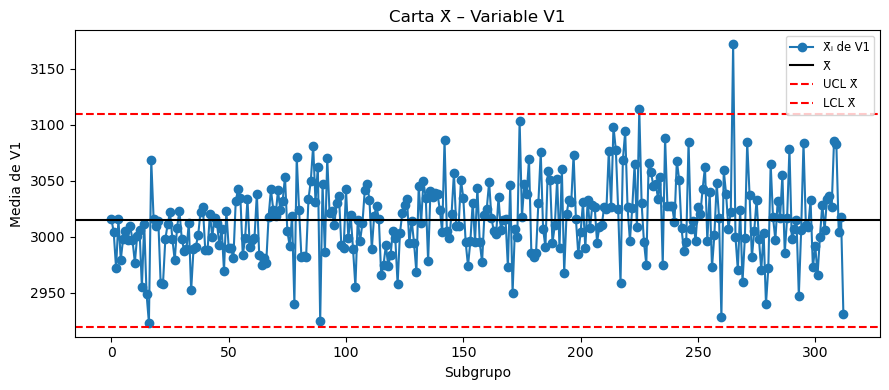

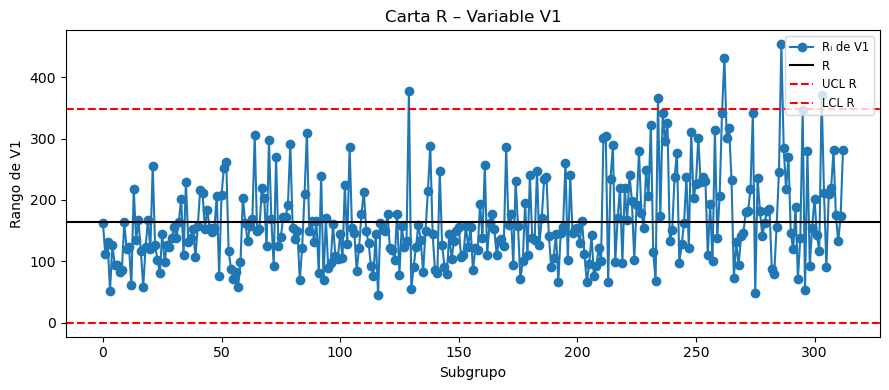

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) CARGA DE DATOS Y RENOMBRADO DE COLUMNAS CONTINUAS
# ---------------------------------------------------

# 1.1) Variables de proceso (590 columnas continuas)
df_x = pd.read_csv(
    "datos_entrada/secom.data",
    delim_whitespace=True,
    header=None,
    na_values="NaN"
)

#    Renombrar columnas a "V1", "V2", ..., "V590"
df_x.columns = [f"V{i+1}" for i in range(df_x.shape[1])] 
#    Ahora df_x tiene columnas ["V1","V2",...,"V590"]

# 1.2) Etiquetas y fecha
df_y = pd.read_csv(
    "datos_entrada/secom_labels.data",
    sep=r"\s+",
    header=None,
    names=["fail", "timestamp"],
    parse_dates=["timestamp"]
)

#    Ordenar cronológicamente y resetear índice
df_y = df_y.sort_values("timestamp").reset_index(drop=True)

#    Convertir fail: 1 ➔ 1 (defectuoso), -1 ➔ 0 (buen lote)
df_y["fail"] = df_y["fail"].map({1: 1, -1: 0})

# 1.3) Unir df_x + df_y en un solo DataFrame
secom = pd.concat([df_x, df_y], axis=1)

# Verificación rápida
print("Shape de secom:", secom.shape)  
print("Conteo de fallas (0 = bueno, 1 = defectuoso):")
print(secom["fail"].value_counts())
print("Porcentaje promedio de NaN en todo el DataFrame:", 
      secom.isna().mean().mean())  # ≈ 0.045 ≈ 4.5 %


# 2) LIMPIEZA DE COLUMNAS CONTINUAS (UMBRAL 40 % NaN)
# -------------------------------------------------

# 2.1) Calcular porcentaje de NaN sólo sobre "V1" … "V590"
pct_missing = secom.loc[:, "V1":"V590"].isna().mean() * 100

# 2.2) Crear un DataFrame para documentar
missing_df = pct_missing.reset_index()
missing_df.columns = ['variable', 'pct_nan']
missing_df = missing_df.sort_values('pct_nan', ascending=False)

# 2.3) Separar variables a descartar (>40 % NaN) y a imputar (0 < NaN ≤ 40 %)
cols_to_drop = missing_df.loc[missing_df['pct_nan'] > 40, 'variable'].tolist()
cols_to_impute = missing_df.loc[
    (missing_df['pct_nan'] > 0) & (missing_df['pct_nan'] <= 40),
    'variable'
].tolist()

print(f"Variables con >40 % NaN (se descartarán): {len(cols_to_drop)} columnas")
print(f"Variables con 0 % < NaN ≤ 40 % (se imputarán con mediana): {len(cols_to_impute)} columnas")
print(f"Variables sin NaN: {(missing_df['pct_nan'] == 0).sum()} columnas")

# 2.4) Aplicar limpieza
secom_clean = secom.drop(columns=cols_to_drop)
for col in cols_to_impute:
    med = secom_clean[col].median()
    secom_clean[col].fillna(med, inplace=True)

# Verificar que ahora no queden NaN en las columnas continuas
print("NaN restantes en continuas tras limpiar:", 
      secom_clean.loc[:, "V1":"V590"].isna().sum().sum())  # debería dar 0


# 3) FORMAR SUBGRUPOS DE TAMAÑO n = 5 (descartar último parcial)
# -------------------------------------------------------------

n = 5
# Si el total de filas no es múltiplo de 5, descartamos las últimas 'resto' filas
resto = secom_clean.shape[0] % n
if resto != 0:
    secom_clean = secom_clean.iloc[:-resto].reset_index(drop=True)

# Crear columna 'subgroup'
secom_clean["subgroup"] = secom_clean.index // n

# Verificar cuántos subgrupos y tamaños
counts_per_group = secom_clean.groupby("subgroup")["fail"].size()
print("Número de subgrupos:", counts_per_group.shape[0])
print("Distribución de tamaños por subgrupo (deberían ser todos 5):")
print(counts_per_group.value_counts())


# 4) GRAFICAR CARTAS X̄ y R PARA UNA VARIABLE CONTINUA EXAMPLE ("V1")
# ------------------------------------------------------------------

var = "V1"  # Cámbialo por cualquiera de "V2","V3",…,"V590"

# 4.1) Asegurarnos de que existe
if var not in secom_clean.columns:
    raise ValueError(f"La variable {var} no existe en el DataFrame limpio.")

# 4.2) Agrupar por 'subgroup' y calcular X̄ᵢ y Rᵢ
grouped = secom_clean.groupby("subgroup")[var]
xbar = grouped.mean()                   # Media de var en cada subgrupo
R    = grouped.max() - grouped.min()    # Rango de var en cada subgrupo

# 4.3) Constantes de control para subgrupos de tamaño 5
A2 = 0.577    # tabla estándar para n = 5
D3 = 0.0      # para n = 5
D4 = 2.114    # para n = 5

# 4.4) Cálculo de centros (X̄̄, R̄) y límites (UCL, LCL)
center_x = xbar.mean()    # X̄̄
center_R = R.mean()       # R̄

UCL_x = center_x + A2 * center_R
LCL_x = center_x - A2 * center_R

UCL_R = D4 * center_R
LCL_R = D3 * center_R   # normalmente 0 cuando D3 = 0

print(f"=== Estadísticos para {var} ===")
print(f"X̄̄ = {center_x:.4f}, R̄ = {center_R:.4f}")
print(f"Límites X̄:  UCL = {UCL_x:.4f},  LCL = {LCL_x:.4f}")
print(f"Límites R:   UCL = {UCL_R:.4f},  LCL = {LCL_R:.4f}\n")

# 4.5) Graficar carta X̄
plt.figure(figsize=(9, 4))
plt.plot(xbar.index, xbar, marker="o", linestyle="-", label=f"X̄ᵢ de {var}")
plt.axhline(center_x, color="k", linestyle="-",   label="X̄̄")
plt.axhline(UCL_x, color="r", linestyle="--",     label="UCL X̄")
plt.axhline(LCL_x, color="r", linestyle="--",     label="LCL X̄")
plt.title(f"Carta X̄ – Variable {var}")
plt.xlabel("Subgrupo")
plt.ylabel(f"Media de {var}")
plt.legend(loc="upper right", fontsize="small")
plt.tight_layout()
plt.show()

# 4.6) Graficar carta R
plt.figure(figsize=(9, 4))
plt.plot(R.index, R, marker="o", linestyle="-", label=f"Rᵢ de {var}")
plt.axhline(center_R, color="k", linestyle="-",   label="R̄")
plt.axhline(UCL_R, color="r", linestyle="--",     label="UCL R")
plt.axhline(LCL_R, color="r", linestyle="--",     label="LCL R")
plt.title(f"Carta R – Variable {var}")
plt.xlabel("Subgrupo")
plt.ylabel(f"Rango de {var}")
plt.legend(loc="upper right", fontsize="small")
plt.tight_layout()
plt.show()


/tmp/ipykernel_6940/4134390087.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_x = pd.read_csv(
/tmp/ipykernel_6940/4134390087.py:21: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_y = pd.read_csv(


Shape de secom: (1567, 592)
Conteo de fallas (0 = bueno, 1 = defectuoso):
fail
0    1463
1     104
Name: count, dtype: int64
Porcentaje promedio de NaN en todo el DataFrame: 0.04522219251798065
Variables con >40 % NaN (se descartarán): 32 columnas
Variables con 0 % < NaN ≤ 40 % (se imputarán con mediana): 506 columnas
Variables sin NaN: 52 columnas


/tmp/ipykernel_6940/4134390087.py:72: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  secom_clean[col].fillna(med, inplace=True)
/tmp/ipykernel_6940/4134390087.py:72: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

NaN restantes en continuas tras limpiar: 0
Número de subgrupos: 313
Distribución de tamaños por subgrupo (deberían ser todos 5):
fail
5    313
Name: count, dtype: int64
=== Estadísticos para V2 ===
X̄̄ = 2495.8718, R̄ = 178.4344
Límites X̄:  UCL = 2598.8285,  LCL = 2392.9152
Límites R:   UCL = 377.2103,  LCL = 0.0000



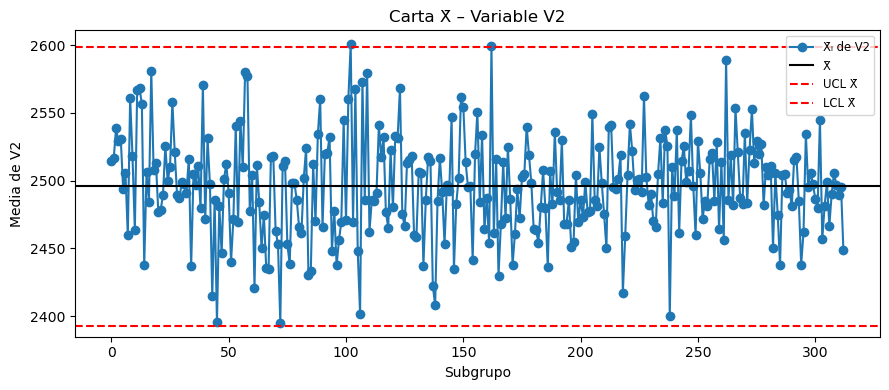

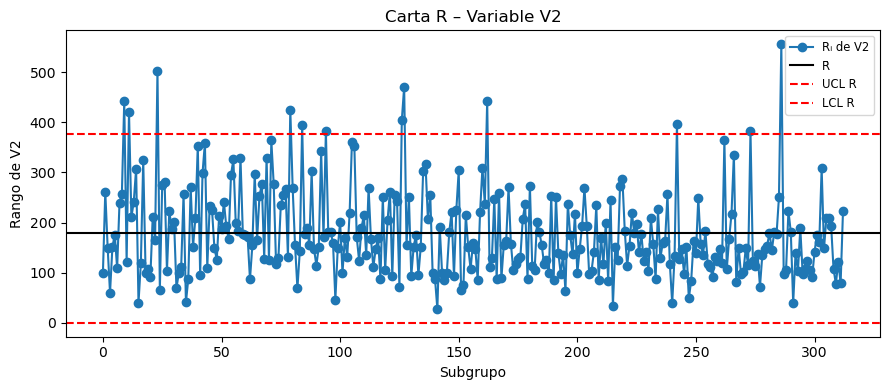

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) CARGA DE DATOS Y RENOMBRADO DE COLUMNAS CONTINUAS
# ---------------------------------------------------

# 1.1) Variables de proceso (590 columnas continuas)
df_x = pd.read_csv(
    "datos_entrada/secom.data",
    delim_whitespace=True,
    header=None,
    na_values="NaN"
)

#    Renombrar columnas a "V1", "V2", ..., "V590"
df_x.columns = [f"V{i+1}" for i in range(df_x.shape[1])] 
#    Ahora df_x tiene columnas ["V1","V2",...,"V590"]

# 1.2) Etiquetas y fecha
df_y = pd.read_csv(
    "datos_entrada/secom_labels.data",
    sep=r"\s+",
    header=None,
    names=["fail", "timestamp"],
    parse_dates=["timestamp"]
)

#    Ordenar cronológicamente y resetear índice
df_y = df_y.sort_values("timestamp").reset_index(drop=True)

#    Convertir fail: 1 ➔ 1 (defectuoso), -1 ➔ 0 (buen lote)
df_y["fail"] = df_y["fail"].map({1: 1, -1: 0})

# 1.3) Unir df_x + df_y en un solo DataFrame
secom = pd.concat([df_x, df_y], axis=1)

# Verificación rápida
print("Shape de secom:", secom.shape)  
print("Conteo de fallas (0 = bueno, 1 = defectuoso):")
print(secom["fail"].value_counts())
print("Porcentaje promedio de NaN en todo el DataFrame:", 
      secom.isna().mean().mean())  # ≈ 0.045 ≈ 4.5 %


# 2) LIMPIEZA DE COLUMNAS CONTINUAS (UMBRAL 40 % NaN)
# -------------------------------------------------

# 2.1) Calcular porcentaje de NaN sólo sobre "V1" … "V590"
pct_missing = secom.loc[:, "V1":"V590"].isna().mean() * 100

# 2.2) Crear un DataFrame para documentar
missing_df = pct_missing.reset_index()
missing_df.columns = ['variable', 'pct_nan']
missing_df = missing_df.sort_values('pct_nan', ascending=False)

# 2.3) Separar variables a descartar (>40 % NaN) y a imputar (0 < NaN ≤ 40 %)
cols_to_drop = missing_df.loc[missing_df['pct_nan'] > 40, 'variable'].tolist()
cols_to_impute = missing_df.loc[
    (missing_df['pct_nan'] > 0) & (missing_df['pct_nan'] <= 40),
    'variable'
].tolist()

print(f"Variables con >40 % NaN (se descartarán): {len(cols_to_drop)} columnas")
print(f"Variables con 0 % < NaN ≤ 40 % (se imputarán con mediana): {len(cols_to_impute)} columnas")
print(f"Variables sin NaN: {(missing_df['pct_nan'] == 0).sum()} columnas")

# 2.4) Aplicar limpieza
secom_clean = secom.drop(columns=cols_to_drop)
for col in cols_to_impute:
    med = secom_clean[col].median()
    secom_clean[col].fillna(med, inplace=True)

# Verificar que ahora no queden NaN en las columnas continuas
print("NaN restantes en continuas tras limpiar:", 
      secom_clean.loc[:, "V1":"V590"].isna().sum().sum())  # debería dar 0


# 3) FORMAR SUBGRUPOS DE TAMAÑO n = 5 (descartar último parcial)
# -------------------------------------------------------------

n = 5
# Si el total de filas no es múltiplo de 5, descartamos las últimas 'resto' filas
resto = secom_clean.shape[0] % n
if resto != 0:
    secom_clean = secom_clean.iloc[:-resto].reset_index(drop=True)

# Crear columna 'subgroup'
secom_clean["subgroup"] = secom_clean.index // n

# Verificar cuántos subgrupos y tamaños
counts_per_group = secom_clean.groupby("subgroup")["fail"].size()
print("Número de subgrupos:", counts_per_group.shape[0])
print("Distribución de tamaños por subgrupo (deberían ser todos 5):")
print(counts_per_group.value_counts())


# 4) GRAFICAR CARTAS X̄ y R PARA UNA VARIABLE CONTINUA EXAMPLE ("V1")
# ------------------------------------------------------------------

var = "V2"  # Cámbialo por cualquiera de "V2","V3",…,"V590"

# 4.1) Asegurarnos de que existe
if var not in secom_clean.columns:
    raise ValueError(f"La variable {var} no existe en el DataFrame limpio.")

# 4.2) Agrupar por 'subgroup' y calcular X̄ᵢ y Rᵢ
grouped = secom_clean.groupby("subgroup")[var]
xbar = grouped.mean()                   # Media de var en cada subgrupo
R    = grouped.max() - grouped.min()    # Rango de var en cada subgrupo

# 4.3) Constantes de control para subgrupos de tamaño 5
A2 = 0.577    # tabla estándar para n = 5
D3 = 0.0      # para n = 5
D4 = 2.114    # para n = 5

# 4.4) Cálculo de centros (X̄̄, R̄) y límites (UCL, LCL)
center_x = xbar.mean()    # X̄̄
center_R = R.mean()       # R̄

UCL_x = center_x + A2 * center_R
LCL_x = center_x - A2 * center_R

UCL_R = D4 * center_R
LCL_R = D3 * center_R   # normalmente 0 cuando D3 = 0

print(f"=== Estadísticos para {var} ===")
print(f"X̄̄ = {center_x:.4f}, R̄ = {center_R:.4f}")
print(f"Límites X̄:  UCL = {UCL_x:.4f},  LCL = {LCL_x:.4f}")
print(f"Límites R:   UCL = {UCL_R:.4f},  LCL = {LCL_R:.4f}\n")

# 4.5) Graficar carta X̄
plt.figure(figsize=(9, 4))
plt.plot(xbar.index, xbar, marker="o", linestyle="-", label=f"X̄ᵢ de {var}")
plt.axhline(center_x, color="k", linestyle="-",   label="X̄̄")
plt.axhline(UCL_x, color="r", linestyle="--",     label="UCL X̄")
plt.axhline(LCL_x, color="r", linestyle="--",     label="LCL X̄")
plt.title(f"Carta X̄ – Variable {var}")
plt.xlabel("Subgrupo")
plt.ylabel(f"Media de {var}")
plt.legend(loc="upper right", fontsize="small")
plt.tight_layout()
plt.show()

# 4.6) Graficar carta R
plt.figure(figsize=(9, 4))
plt.plot(R.index, R, marker="o", linestyle="-", label=f"Rᵢ de {var}")
plt.axhline(center_R, color="k", linestyle="-",   label="R̄")
plt.axhline(UCL_R, color="r", linestyle="--",     label="UCL R")
plt.axhline(LCL_R, color="r", linestyle="--",     label="LCL R")
plt.title(f"Carta R – Variable {var}")
plt.xlabel("Subgrupo")
plt.ylabel(f"Rango de {var}")
plt.legend(loc="upper right", fontsize="small")
plt.tight_layout()
plt.show()


/tmp/ipykernel_6940/4217469634.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_x = pd.read_csv(
/tmp/ipykernel_6940/4217469634.py:21: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_y = pd.read_csv(
/tmp/ipykernel_6940/4217469634.py:72: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  secom_clean[col].

Shape de secom: (1567, 592)
Conteo de fallas (0 = bueno, 1 = defectuoso):
fail
0    1463
1     104
Name: count, dtype: int64
Porcentaje promedio de NaN en todo el DataFrame: 0.04522219251798065
Variables con >40 % NaN (se descartarán): 32 columnas
Variables con 0 % < NaN ≤ 40 % (se imputarán con mediana): 506 columnas
Variables sin NaN: 52 columnas


/tmp/ipykernel_6940/4217469634.py:72: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  secom_clean[col].fillna(med, inplace=True)
/tmp/ipykernel_6940/4217469634.py:72: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

NaN restantes en continuas tras limpiar: 0
Número de subgrupos: 313
Distribución de tamaños por subgrupo (deberían ser todos 5):
fail
5    313
Name: count, dtype: int64
=== Estadísticos para V3 ===
X̄̄ = 2200.5702, R̄ = 55.4177
Límites X̄:  UCL = 2232.5462,  LCL = 2168.5942
Límites R:   UCL = 117.1530,  LCL = 0.0000



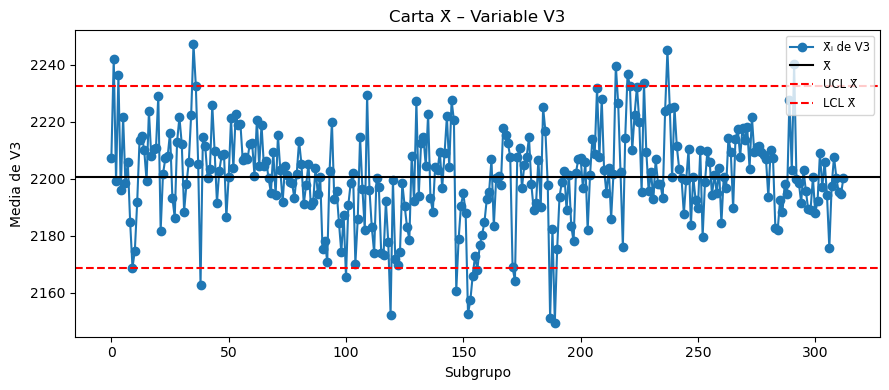

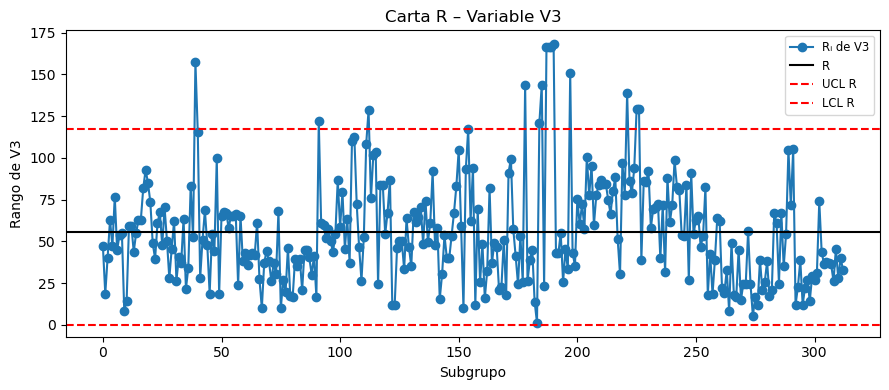

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) CARGA DE DATOS Y RENOMBRADO DE COLUMNAS CONTINUAS
# ---------------------------------------------------

# 1.1) Variables de proceso (590 columnas continuas)
df_x = pd.read_csv(
    "datos_entrada/secom.data",
    delim_whitespace=True,
    header=None,
    na_values="NaN"
)

#    Renombrar columnas a "V1", "V2", ..., "V590"
df_x.columns = [f"V{i+1}" for i in range(df_x.shape[1])] 
#    Ahora df_x tiene columnas ["V1","V2",...,"V590"]

# 1.2) Etiquetas y fecha
df_y = pd.read_csv(
    "datos_entrada/secom_labels.data",
    sep=r"\s+",
    header=None,
    names=["fail", "timestamp"],
    parse_dates=["timestamp"]
)

#    Ordenar cronológicamente y resetear índice
df_y = df_y.sort_values("timestamp").reset_index(drop=True)

#    Convertir fail: 1 ➔ 1 (defectuoso), -1 ➔ 0 (buen lote)
df_y["fail"] = df_y["fail"].map({1: 1, -1: 0})

# 1.3) Unir df_x + df_y en un solo DataFrame
secom = pd.concat([df_x, df_y], axis=1)

# Verificación rápida
print("Shape de secom:", secom.shape)  
print("Conteo de fallas (0 = bueno, 1 = defectuoso):")
print(secom["fail"].value_counts())
print("Porcentaje promedio de NaN en todo el DataFrame:", 
      secom.isna().mean().mean())  # ≈ 0.045 ≈ 4.5 %


# 2) LIMPIEZA DE COLUMNAS CONTINUAS (UMBRAL 40 % NaN)
# -------------------------------------------------

# 2.1) Calcular porcentaje de NaN sólo sobre "V1" … "V590"
pct_missing = secom.loc[:, "V1":"V590"].isna().mean() * 100

# 2.2) Crear un DataFrame para documentar
missing_df = pct_missing.reset_index()
missing_df.columns = ['variable', 'pct_nan']
missing_df = missing_df.sort_values('pct_nan', ascending=False)

# 2.3) Separar variables a descartar (>40 % NaN) y a imputar (0 < NaN ≤ 40 %)
cols_to_drop = missing_df.loc[missing_df['pct_nan'] > 40, 'variable'].tolist()
cols_to_impute = missing_df.loc[
    (missing_df['pct_nan'] > 0) & (missing_df['pct_nan'] <= 40),
    'variable'
].tolist()

print(f"Variables con >40 % NaN (se descartarán): {len(cols_to_drop)} columnas")
print(f"Variables con 0 % < NaN ≤ 40 % (se imputarán con mediana): {len(cols_to_impute)} columnas")
print(f"Variables sin NaN: {(missing_df['pct_nan'] == 0).sum()} columnas")

# 2.4) Aplicar limpieza
secom_clean = secom.drop(columns=cols_to_drop)
for col in cols_to_impute:
    med = secom_clean[col].median()
    secom_clean[col].fillna(med, inplace=True)

# Verificar que ahora no queden NaN en las columnas continuas
print("NaN restantes en continuas tras limpiar:", 
      secom_clean.loc[:, "V1":"V590"].isna().sum().sum())  # debería dar 0


# 3) FORMAR SUBGRUPOS DE TAMAÑO n = 5 (descartar último parcial)
# -------------------------------------------------------------

n = 5
# Si el total de filas no es múltiplo de 5, descartamos las últimas 'resto' filas
resto = secom_clean.shape[0] % n
if resto != 0:
    secom_clean = secom_clean.iloc[:-resto].reset_index(drop=True)

# Crear columna 'subgroup'
secom_clean["subgroup"] = secom_clean.index // n

# Verificar cuántos subgrupos y tamaños
counts_per_group = secom_clean.groupby("subgroup")["fail"].size()
print("Número de subgrupos:", counts_per_group.shape[0])
print("Distribución de tamaños por subgrupo (deberían ser todos 5):")
print(counts_per_group.value_counts())


# 4) GRAFICAR CARTAS X̄ y R PARA UNA VARIABLE CONTINUA EXAMPLE ("V1")
# ------------------------------------------------------------------

var = "V3"  # Cámbialo por cualquiera de "V2","V3",…,"V590"

# 4.1) Asegurarnos de que existe
if var not in secom_clean.columns:
    raise ValueError(f"La variable {var} no existe en el DataFrame limpio.")

# 4.2) Agrupar por 'subgroup' y calcular X̄ᵢ y Rᵢ
grouped = secom_clean.groupby("subgroup")[var]
xbar = grouped.mean()                   # Media de var en cada subgrupo
R    = grouped.max() - grouped.min()    # Rango de var en cada subgrupo

# 4.3) Constantes de control para subgrupos de tamaño 5
A2 = 0.577    # tabla estándar para n = 5
D3 = 0.0      # para n = 5
D4 = 2.114    # para n = 5

# 4.4) Cálculo de centros (X̄̄, R̄) y límites (UCL, LCL)
center_x = xbar.mean()    # X̄̄
center_R = R.mean()       # R̄

UCL_x = center_x + A2 * center_R
LCL_x = center_x - A2 * center_R

UCL_R = D4 * center_R
LCL_R = D3 * center_R   # normalmente 0 cuando D3 = 0

print(f"=== Estadísticos para {var} ===")
print(f"X̄̄ = {center_x:.4f}, R̄ = {center_R:.4f}")
print(f"Límites X̄:  UCL = {UCL_x:.4f},  LCL = {LCL_x:.4f}")
print(f"Límites R:   UCL = {UCL_R:.4f},  LCL = {LCL_R:.4f}\n")

# 4.5) Graficar carta X̄
plt.figure(figsize=(9, 4))
plt.plot(xbar.index, xbar, marker="o", linestyle="-", label=f"X̄ᵢ de {var}")
plt.axhline(center_x, color="k", linestyle="-",   label="X̄̄")
plt.axhline(UCL_x, color="r", linestyle="--",     label="UCL X̄")
plt.axhline(LCL_x, color="r", linestyle="--",     label="LCL X̄")
plt.title(f"Carta X̄ – Variable {var}")
plt.xlabel("Subgrupo")
plt.ylabel(f"Media de {var}")
plt.legend(loc="upper right", fontsize="small")
plt.tight_layout()
plt.show()

# 4.6) Graficar carta R
plt.figure(figsize=(9, 4))
plt.plot(R.index, R, marker="o", linestyle="-", label=f"Rᵢ de {var}")
plt.axhline(center_R, color="k", linestyle="-",   label="R̄")
plt.axhline(UCL_R, color="r", linestyle="--",     label="UCL R")
plt.axhline(LCL_R, color="r", linestyle="--",     label="LCL R")
plt.title(f"Carta R – Variable {var}")
plt.xlabel("Subgrupo")
plt.ylabel(f"Rango de {var}")
plt.legend(loc="upper right", fontsize="small")
plt.tight_layout()
plt.show()


## Six Sigma

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats

# Cargar datos
df_x = pd.read_csv(
    "datos_entrada/secom.data",
    delim_whitespace=True,
    header=None,
    na_values="NaN"
)
df_x.columns = [f"V{i+1}" for i in range(df_x.shape[1])]

df_y = pd.read_csv(
    "datos_entrada/secom_labels.data",
    sep=r"\s+",
    header=None,
    names=["fail", "timestamp"],
    parse_dates=["timestamp"]
)
df_y = df_y.sort_values("timestamp").reset_index(drop=True)
df_y["fail"] = df_y["fail"].map({1: 1, -1: 0})

# Unir DataFrames
secom = pd.concat([df_x, df_y], axis=1)

# Limpieza básica
pct_missing = secom.loc[:, "V1":"V590"].isna().mean() * 100
missing_df = pct_missing.reset_index()
missing_df.columns = ['variable', 'pct_nan']

cols_to_drop = missing_df.loc[missing_df['pct_nan'] > 40, 'variable'].tolist()
cols_to_impute = missing_df.loc[
    (missing_df['pct_nan'] > 0) & (missing_df['pct_nan'] <= 40),
    'variable'
].tolist()

secom_clean = secom.drop(columns=cols_to_drop)
for col in cols_to_impute:
    secom_clean[col].fillna(secom_clean[col].median(), inplace=True)

# Formar subgrupos de tamaño n=5
n = 5
resto = secom_clean.shape[0] % n
if resto != 0:
    secom_clean = secom_clean.iloc[:-resto].reset_index(drop=True)
secom_clean["subgroup"] = secom_clean.index // n

# 1) Cálculo DPMO y nivel sigma global
total_lotes = secom_clean.shape[0]
defectos = secom_clean["fail"].sum()
# En este caso, cada lote se considera una unidad y 1 defecto por unidad
opportunities = 1  
dpmo = (defectos / (total_lotes * opportunities)) * 1e6
sigma_level = 1.5 + stats.norm.isf(dpmo / 1e6)

print("=== Six Sigma - Defectos ===")
print(f"Total lotes: {total_lotes}")
print(f"Defectos totales: {defectos}")
print(f"DPMO: {dpmo:.1f}")
print(f"Nivel Sigma (1.5σ corr.): {sigma_level:.2f}\n")

# 2) Índices de capacidad (Cp, Cpk) para variables continuas
# Especificar límites de especificación para cada variable seleccionada
# (Estos ejemplos son ilustrativos; ajuste según datos reales o requerimientos)
spec_limits = {
    "V1": {"LSL": secom_clean["V1"].mean() - 3*secom_clean["V1"].std(),
           "USL": secom_clean["V1"].mean() + 3*secom_clean["V1"].std()},
    "V2": {"LSL": secom_clean["V2"].mean() - 3*secom_clean["V2"].std(),
           "USL": secom_clean["V2"].mean() + 3*secom_clean["V2"].std()},
    "V3": {"LSL": secom_clean["V3"].mean() - 3*secom_clean["V3"].std(),
           "USL": secom_clean["V3"].mean() + 3*secom_clean["V3"].std()}
}

capability_results = []
for var, limits in spec_limits.items():
    data = secom_clean[var]
    mean = data.mean()
    std = data.std(ddof=1)
    USL = limits["USL"]
    LSL = limits["LSL"]
    
    Cp = (USL - LSL) / (6 * std)
    Cpk = min((USL - mean) / (3 * std), (mean - LSL) / (3 * std))
    
    capability_results.append({
        "Variable": var,
        "LSL": LSL,
        "USL": USL,
        "Mean": mean,
        "Std": std,
        "Cp": Cp,
        "Cpk": Cpk
    })

capability_df = pd.DataFrame(capability_results)
import ace_tools as tools; tools.display_dataframe_to_user("Capability Indices", capability_df)


/tmp/ipykernel_20985/1021294515.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_x = pd.read_csv(
/tmp/ipykernel_20985/1021294515.py:14: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_y = pd.read_csv(
/tmp/ipykernel_20985/1021294515.py:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  secom_clean[co

=== Six Sigma - Defectos ===
Total lotes: 1565
Defectos totales: 104
DPMO: 66453.7
Nivel Sigma (1.5σ corr.): 3.00



ModuleNotFoundError: No module named 'ace_tools'

In [2]:
import pandas as pd
import numpy as np
import scipy.stats as stats

# —————————————————————————————————————————————
# 1) CARGA DE DATOS Y RENOMBRADO DE COLUMNAS CONTINUAS
# —————————————————————————————————————————————

# 1.1) Variables de proceso (590 columnas continuas)
df_x = pd.read_csv(
    "datos_entrada/secom.data",
    delim_whitespace=True,
    header=None,
    na_values="NaN"
)
# Renombrar columnas a V1, V2, …, V590
df_x.columns = [f"V{i+1}" for i in range(df_x.shape[1])]

# 1.2) Etiquetas (fail + timestamp)
df_y = pd.read_csv(
    "datos_entrada/secom_labels.data",
    sep=r"\s+",
    header=None,
    names=["fail", "timestamp"],
    parse_dates=["timestamp"]
)
# Ordenar cronológicamente
df_y = df_y.sort_values("timestamp").reset_index(drop=True)
# Mapear fail:  1 → 1 (defectuoso),  −1 → 0 (buen lote)
df_y["fail"] = df_y["fail"].map({1: 1, -1: 0})

# 1.3) Unir df_x + df_y en un solo DataFrame
secom = pd.concat([df_x, df_y], axis=1)


# ——————————————————————————————————————————————————————————
# 2) LIMPIEZA BÁSICA DE LAS VARIABLES CONTINUAS (umbral 40% NaN)
# ——————————————————————————————————————————————————————————

# 2.1) Calcular % NaN en V1…V590
pct_missing = secom.loc[:, "V1":"V590"].isna().mean() * 100

# 2.2) Crear DataFrame para documentar
missing_df = pct_missing.reset_index()
missing_df.columns = ['variable', 'pct_nan']
missing_df = missing_df.sort_values('pct_nan', ascending=False)

# 2.3) Identificar columnas a descartar (> 40% NaN) y a imputar (0 < NaN ≤ 40%)
cols_to_drop = missing_df.loc[missing_df['pct_nan'] > 40, 'variable'].tolist()
cols_to_impute = missing_df.loc[
    (missing_df['pct_nan'] > 0) & (missing_df['pct_nan'] <= 40),
    'variable'
].tolist()

print(f"(Limpieza) Variables con > 40% de NaN → se descartarán: {len(cols_to_drop)} columnas")
print(f"(Limpieza) Variables con 0% < NaN ≤ 40% → se imputarán con mediana: {len(cols_to_impute)} columnas")
print(f"(Limpieza) Variables sin NaN: {(missing_df['pct_nan'] == 0).sum()} columnas\n")

# 2.4) Aplicar limpieza:
secom_clean = secom.drop(columns=cols_to_drop)
for col in cols_to_impute:
    secom_clean[col].fillna(secom_clean[col].median(), inplace=True)

# Verificar que ya no queden NaN en las columnas V1…V590
remaining_nans = secom_clean.loc[:, "V1":"V590"].isna().sum().sum()
print(f"(Limpieza) NaN restantes en continuas tras imputar: {remaining_nans}\n")


# ———————————————————————————————————————————————————————
# 3) FORMAR SUBGRUPOS DE TAMAÑO n = 5 (descartar último parcial)
# ———————————————————————————————————————————————————————

n = 5
resto = secom_clean.shape[0] % n
if resto != 0:
    # Descartar las últimas 'resto' filas para que todos los subgrupos queden de tamaño EXACTO = 5
    secom_clean = secom_clean.iloc[:-resto].reset_index(drop=True)

# Crear columna 'subgroup'
secom_clean["subgroup"] = secom_clean.index // n

# Verificar tamaños de subgrupos
counts_per_group = secom_clean.groupby("subgroup")["fail"].size()
print(f"Número de subgrupos formados (tamaño 5 cada uno): {counts_per_group.shape[0]}")
print(f"Tamaños por subgrupo (deben ser 5 todos):\n{counts_per_group.value_counts()}\n")


# —————————————————————————————————————————————————————
# 4) CÁLCULO DE DPMO Y NIVEL SIGMA GLOBAL (atributos: fallas)
# —————————————————————————————————————————————————————

total_lotes = secom_clean.shape[0]
defectos = secom_clean["fail"].sum()
# Cada lote es 1 unidad y se asume 1 oportunidad de defecto por lote
opportunities = 1  

dpmo = (defectos / (total_lotes * opportunities)) * 1e6
# Agregar corrección de 1.5σ para pasar de DPMO a nivel sigma
sigma_level = 1.5 + stats.norm.isf(dpmo / 1e6)

print("=== Six Sigma (Atributos) ===")
print(f"Total de lotes analizados: {total_lotes}")
print(f"Total de lotes defectuosos: {defectos}")
print(f"DPMO calculado: {dpmo:.1f}")
print(f"Nivel Sigma (con corrección 1.5σ): {sigma_level:.2f}\n")


# ————————————————————————————————————————————————————————————
# 5) ÍNDICES DE CAPACIDAD (Cp, Cpk) PARA VARIABLES CONTINUAS SELECCIONADAS
# ————————————————————————————————————————————————————————————

# 5.1) Definir límites de especificación para cada variable continua
#      En este ejemplo usamos: LSL = media − 3*σ,  USL = media + 3*σ  
#      (Tú puedes cambiar LSL y USL según tus requisitos reales.)
spec_limits = {
    "V1": {"LSL": secom_clean["V1"].mean() - 3 * secom_clean["V1"].std(),
           "USL": secom_clean["V1"].mean() + 3 * secom_clean["V1"].std()},
    "V2": {"LSL": secom_clean["V2"].mean() - 3 * secom_clean["V2"].std(),
           "USL": secom_clean["V2"].mean() + 3 * secom_clean["V2"].std()},
    "V3": {"LSL": secom_clean["V3"].mean() - 3 * secom_clean["V3"].std(),
           "USL": secom_clean["V3"].mean() + 3 * secom_clean["V3"].std()}
}

capability_results = []
for var, limits in spec_limits.items():
    data = secom_clean[var]
    mean = data.mean()
    std = data.std(ddof=1)
    USL = limits["USL"]
    LSL = limits["LSL"]
    
    Cp = (USL - LSL) / (6 * std)
    Cpk = min((USL - mean) / (3 * std), (mean - LSL) / (3 * std))
    
    capability_results.append({
        "Variable": var,
        "LSL": LSL,
        "USL": USL,
        "Media": mean,
        "Std Dev": std,
        "Cp": Cp,
        "Cpk": Cpk
    })

capability_df = pd.DataFrame(capability_results)

print("=== Índices de Capacidad (Variables continuas) ===")
print(capability_df.to_string(index=False))


/tmp/ipykernel_20985/1200133101.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_x = pd.read_csv(
/tmp/ipykernel_20985/1200133101.py:20: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_y = pd.read_csv(
/tmp/ipykernel_20985/1200133101.py:62: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  secom_clean[c

(Limpieza) Variables con > 40% de NaN → se descartarán: 32 columnas
(Limpieza) Variables con 0% < NaN ≤ 40% → se imputarán con mediana: 506 columnas
(Limpieza) Variables sin NaN: 52 columnas



/tmp/ipykernel_20985/1200133101.py:62: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  secom_clean[col].fillna(secom_clean[col].median(), inplace=True)
/tmp/ipykernel_20985/1200133101.py:62: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

(Limpieza) NaN restantes en continuas tras imputar: 0

Número de subgrupos formados (tamaño 5 cada uno): 313
Tamaños por subgrupo (deben ser 5 todos):
fail
5    313
Name: count, dtype: int64

=== Six Sigma (Atributos) ===
Total de lotes analizados: 1565
Total de lotes defectuosos: 104
DPMO calculado: 66453.7
Nivel Sigma (con corrección 1.5σ): 3.00

=== Índices de Capacidad (Variables continuas) ===
Variable         LSL         USL       Media   Std Dev  Cp  Cpk
      V1 2794.228736 3234.895954 3014.562345 73.444536 1.0  1.0
      V2 2255.073483 2736.670191 2495.871837 80.266118 1.0  1.0
      V3 2112.389905 2288.750594 2200.570250 29.393448 1.0  1.0
